In [18]:
#Importing Required Libraries
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import IPython.display as ipd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [19]:
#Defining the Dataset Path (Local)
DATASET_PATH = os.path.join(os.getcwd(), 'RavdessData')
print(f'Using dataset path: {DATASET_PATH}')

Using dataset path: d:\02 Course\01 Project\09_AI- BASED_VOICE_EMOTION_DETECTION_USING_DL\RavdessData


In [20]:
#Feature Extraction using MFCCs
def extract_features(file_path, max_pad_len=174):
    audio, sample_rate = librosa.load(file_path, sr=22050)
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    pad_width = max_pad_len - mfccs.shape[1]
    if pad_width > 0:
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :max_pad_len]
    return mfccs

In [21]:
#Loading the Dataset
file_paths = []
labels = []
for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith('.wav'):
            file_paths.append(os.path.join(root, file))
            labels.append(int(file.split('-')[2]) - 1)

In [22]:
#If no audio files are found, it raises an error
if len(file_paths) == 0:
    raise ValueError("No audio files found in the specified dataset path. Please check the path and try again.")

print(f"Total audio files found: {len(file_paths)}")

Total audio files found: 1440


In [23]:
#Encoding Labels & Feature Extraction
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

features = np.array([extract_features(file) for file in file_paths])
features = np.expand_dims(features, -1)  # Add channel dimension for CNN

In [24]:
#Splitting the Dataset
X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    features, labels, file_paths, test_size=0.2, random_state=42, stratify=labels
)

In [25]:
X_train = X_train.reshape(X_train.shape[0], 40, 174, 1)
X_test = X_test.reshape(X_test.shape[0], 40, 174, 1)

In [26]:
#Building the CNN Model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(40, 174, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(set(labels)), activation='softmax')
])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\Ekam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
#Training the Model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.1571 - loss: 7.5761 - val_accuracy: 0.1597 - val_loss: 2.0956
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 66s 830ms/step - accuracy: 0.1528 - loss: 2.0597 - val_accuracy: 0.1250 - val_loss: 2.0902
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 996ms/step - accuracy: 0.1380 - loss: 2.0501 - val_accuracy: 0.1736 - val_loss: 2.0737
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.1762 - loss: 2.0148 - val_accuracy: 0.1458 - val_loss: 2.0714
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.1814 - loss: 2.0233 - val_accuracy: 0.1979 - val_loss: 2.0409
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 74s 985ms/step - accuracy: 0.1901 - loss: 1.9863 - val_accuracy: 0.1944 - val_loss: 2.0449
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.1780 - loss: 1.9725 - val_accuracy: 0.1910 - val_loss: 2.0023
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.1884 - loss: 1.9497 - val_accuracy: 0.2153 - 

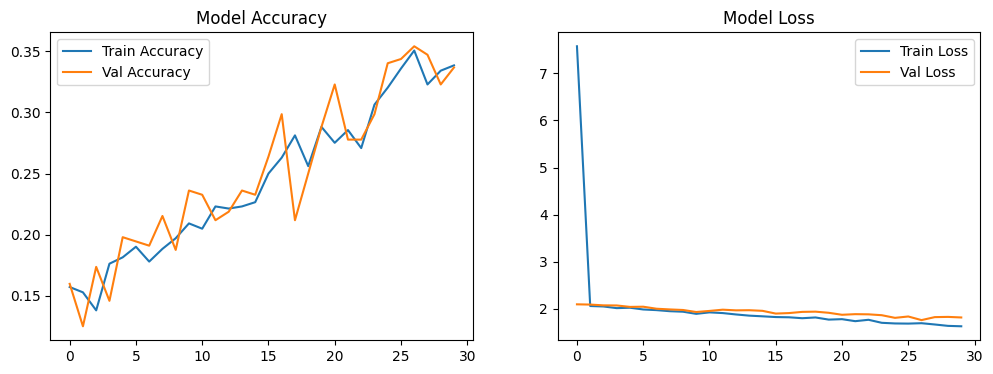

In [28]:
#Training the Model
model.save("voice_emotion_model.h5")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [29]:
emotion_map = {
    0: "Neutral",
    1: "Calm",
    2: "Happy",
    3: "Sad",
    4: "Angry",
    5: "Fearful",
    6: "Disgusted",
    7: "Surprised "
}

In [30]:
#Testing on a Sample Audio
sample_index = np.random.randint(0, len(X_test))
sample_audio = test_paths[sample_index]  # Ensure it's from the test set
sample_feature = np.expand_dims(X_test[sample_index], axis=0)
loaded_model = load_model("voice_emotion_model.h5")
prediction = loaded_model.predict(sample_feature)
predicted_label = np.argmax(prediction)

print(f'Predicted Emotion: {emotion_map[predicted_label]}')
ipd.display(ipd.Audio(sample_audio))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
Predicted Emotion: Surprised 


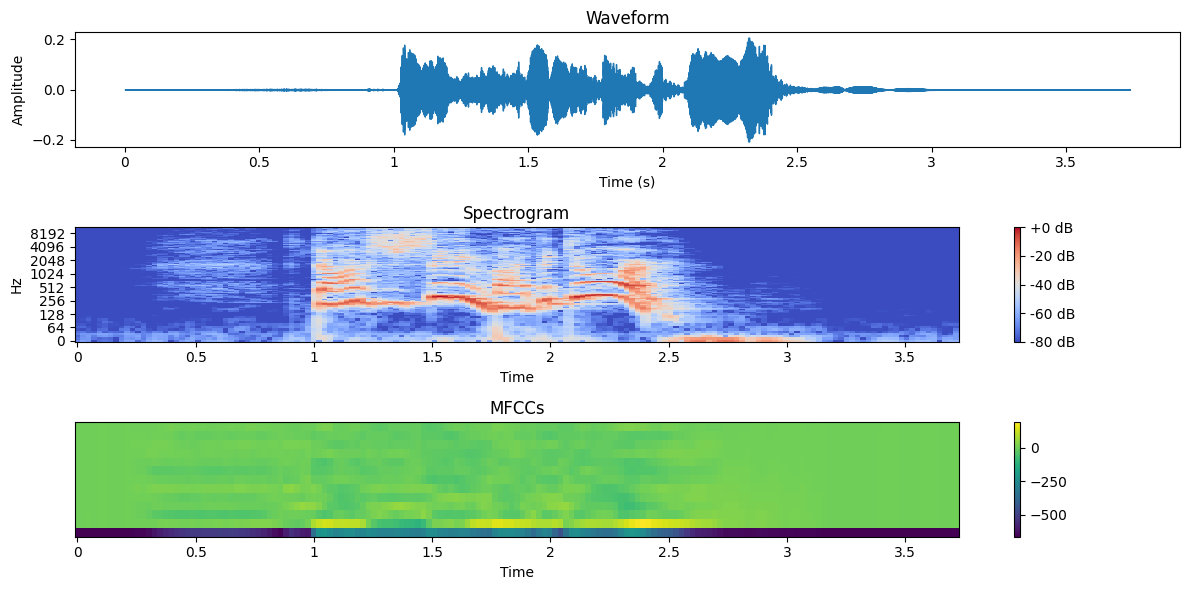

In [31]:
def visualize_audio(audio_path):
    y, sr = librosa.load(audio_path, sr=22050)

    plt.figure(figsize=(12, 6))

    # Waveform Plot
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # Spectrogram
    plt.subplot(3, 1, 2)
    spectrogram = librosa.stft(y)
    spectrogram_db = librosa.amplitude_to_db(np.abs(spectrogram), ref=np.max)
    librosa.display.specshow(spectrogram_db, sr=sr, x_axis="time", y_axis="log", cmap="coolwarm")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Spectrogram")

    # MFCCs
    plt.subplot(3, 1, 3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, sr=sr, x_axis="time", cmap="viridis")
    plt.colorbar()
    plt.title("MFCCs")

    plt.tight_layout()
    plt.show()
visualize_audio(sample_audio)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


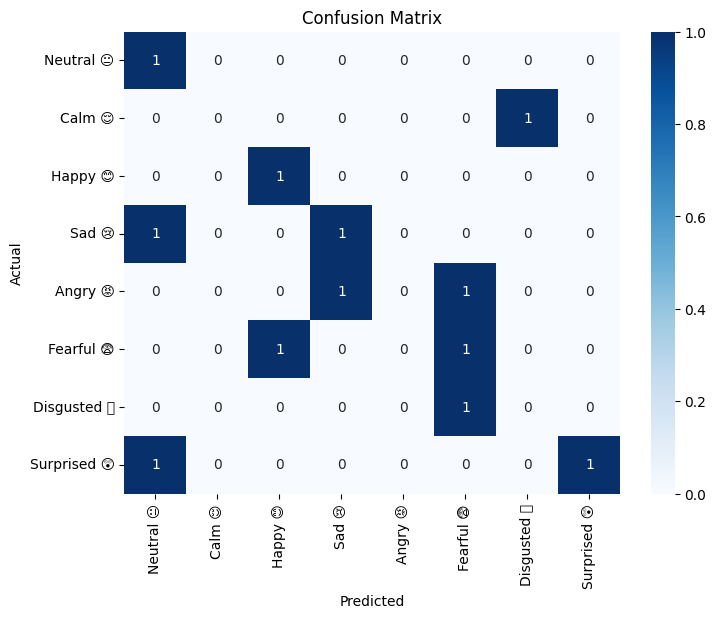

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# Predict on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)

# Plot the confusion matrix
plot_confusion_matrix(y_test, y_pred, list(emotion_map.values()))

In [32]:
# Predict on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)

# Calculate and print model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step
Model Accuracy: 33.68%
